# Social Network Analysis: Repeated Characters in the Bible and Q'uran

In [6]:
# import packages
import pandas as pd
import kagglehub
import os
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import re
import itertools
import spacy

## Load Textual Data

### BibleData

In [ ]:
# latest version of BibleData
path = kagglehub.dataset_download("bradystephenson/bibledata")

person_verse_path = os.path.join(path, "BibleData-PersonVerse.csv")
person_names_path = os.path.join(path, "BibleData-Person.csv")
person_relationship_path = os.path.join(path, "BibleData-PersonVerseApostolic.csv")

df_relation_pv = pd.read_csv(person_verse_path)
df_relation_names = pd.read_csv(person_names_path)
df_relation = pd.read_csv(person_relationship_path)

df_relation.head()

,person_verse_id,reference_id,person_label_id,person_id,person_label,person_label_count,person_verse_sequence,person_verse_notes
0,MAT 1:1__YHVH_1_123,MAT 1:1,YHVH_1_123,YHVH_1,Jesus,1.0,34517,NaN
1,MAT 1:1__YHVH_1_124,MAT 1:1,YHVH_1_124,YHVH_1,The Messiah,1.0,34518,NaN
2,MAT 1:1__YHVH_1_125,MAT 1:1,YHVH_1_125,YHVH_1,Son of David,1.0,34519,NaN
3,MAT 1:1__YHVH_1_126,MAT 1:1,YHVH_1_126,YHVH_1,Son of Abraham,1.0,34520,NaN
4,MAT 1:2__Abram_1_2,MAT 1:2,Abram_1_2,Abram_1,Abraham,1.0,34521,NaN


In [10]:
# gospel book matching
gospel_books = ["MAT", "MRK", "LUK", "JHN"]
# extract book code
df_relation['book'] = df_relation['reference_id'].str[:3]
# filter to four gospels only
gospels_df = df_relation[df_relation['book'].isin(gospel_books)].copy()
gospels_df = gospels_df.dropna(subset=['person_id'])

print(f"Total entries: {len(gospels_df)}")
print(f"Unique characters: {gospels_df['person_id'].nunique()}")

Total entries: 2506
Unique characters: 198


In [12]:
verse_groups = gospels_df.groupby('reference_id')['person_id'].apply(set).reset_index()

multi_person_verses = verse_groups[verse_groups['person_id'].apply(len) > 1]
print(f"Verses with co-occurring characters: {len(multi_person_verses)}")

Verses with co-occurring characters: 392


### Qur'an Data

In [14]:
# !python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 34.9 MB/s  0:00:00eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [16]:
# Qur'an API
nlp = spacy.load("en_core_web_sm")

url = "https://api.alquran.cloud/v1/quran/en.sahih"
response = requests.get(url).json()

verses_data = []
for surah in response['data']['surahs']:
    surah_num = surah['number']
    for ayah in surah['ayahs']:
        verses_data.append({
            'reference_id': f"QURAN {surah_num}:{ayah['numberInSurah']}",
            'text': ayah['text']
        })

df_quran = pd.DataFrame(verses_data)
df_quran.head()

,reference_id,text
0,QURAN 1:1,"In the name of Allah, the Entirely Merciful, t..."
1,QURAN 1:2,"[All] praise is [due] to Allah, Lord of the wo..."
2,QURAN 1:3,"The Entirely Merciful, the Especially Merciful,"
3,QURAN 1:4,Sovereign of the Day of Recompense.
4,QURAN 1:5,It is You we worship and You we ask for help.


In [ ]:
def extract_characters(text):
    doc = nlp(text)
    discovered_names = set()

    for ent in doc.ents:
        if ent.label_ == "PERSON":
            clean_name = ent.text.strip().strip("'s").title()
            if len(clean_name) > 1:
                discovered_names.add(clean_name)
                
    return list(discovered_names)

G_quran = nx.Graph()

for _, row in df_quran.iterrows():
    verse_text = row['text']
    
    # extract all entities found by NLP
    present_characters = extract_characters(verse_text)
            
    # co-presence clustering connection execution
    if len(present_characters) > 1:
        pairs = itertools.combinations(set(present_characters), 2)
        for p1, p2 in pairs:
            if G_quran.has_edge(p1, p2):
                G_quran[p1][p2]['weight'] += 1
            else:
                G_quran.add_edge(p1, p2, weight=1)

In [13]:
df_quran.head()

,reference_id,text
0,QURAN 1:1,"In the name of Allah, the Entirely Merciful, t..."
1,QURAN 1:2,"[All] praise is [due] to Allah, Lord of the wo..."
2,QURAN 1:3,"The Entirely Merciful, the Especially Merciful,"
3,QURAN 1:4,Sovereign of the Day of Recompense.
4,QURAN 1:5,It is You we worship and You we ask for help.


In [ ]:
# Wikipedia
url = "https://en.wikipedia.org/wiki/List_of_people_in_both_the_Bible_and_the_Quran"

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
}

response = requests.get(url, headers=headers)
if response.status_code != 200:
    raise RuntimeError(
        f"Wikipedia blocked the request with Status Code: {response.status_code}"
    )

soup = BeautifulSoup(response.text, "html.parser")
wiki_table = soup.find("table", {"class": "wikitable"})
if not wiki_table:
    raise ValueError("could not extract table")

rows = wiki_table.find_all("tr")

clean_headers = [
    "image_placeholder",
    "bible_name",
    "quran_name",
    "rabbinic_name",
    "relationship_notes",
    "bible_verse",
    "quran_verse",
]

data = []
last_bible_name = "" 

# skip the first 2 multi-tiered header rows
for row in rows[2:]:
    cols = row.find_all(["td", "th"])
    cols_text = [col.text.strip() for col in cols]

    if not cols_text:
        continue

    if len(cols_text) == 6:
        cols_text.insert(1, last_bible_name)
    elif len(cols_text) >= 7:
        last_bible_name = cols_text[1]  # update cache with the current name

    # fill structural gaps up to our 7 explicit headings
    while len(cols_text) < len(clean_headers):
        cols_text.append(None)

    data.append(cols_text[: len(clean_headers)])

df_shared = pd.DataFrame(data, columns=clean_headers)

# clean text fields
def clean_text(text):
    if pd.isna(text):
        return text
    text_str = str(text).strip()
    text_str = re.sub(r"\[.*?\]", "", text_str)  # drop wiki citation brackets
    return text_str.replace("\n", " ").strip()


for col in df_shared.columns:
    df_shared[col] = df_shared[col].apply(clean_text)

# drop thumbnail
df_shared = df_shared.drop(columns=["image_placeholder"])

print(df_shared[["bible_name", "quran_name", "bible_verse", "quran_verse"]].head(5))

     bible_name                          quran_name     bible_verse  \
0       Abraham  Ibrāhīm/Ebraheem/Ebraahym/Ibrāheem  Genesis 17:3–5   
1          Adam                                Ādam     Genesis 5:2   
2         Amram                       ʿImrān/'Emrān     Exodus 6:20   
3    King David                         Dāwūd/Dā'ūd  1 Samuel 17:58   
4  The Apostles                       al-Hawariyyūn    Mark 3:16–19   

   quran_verse  
0  Quran 2:124  
1   Quran 3:59  
2   Quran 3:33  
3  Quran 2:251  
4  Quran 61:14  


### Network Graph Visualizations

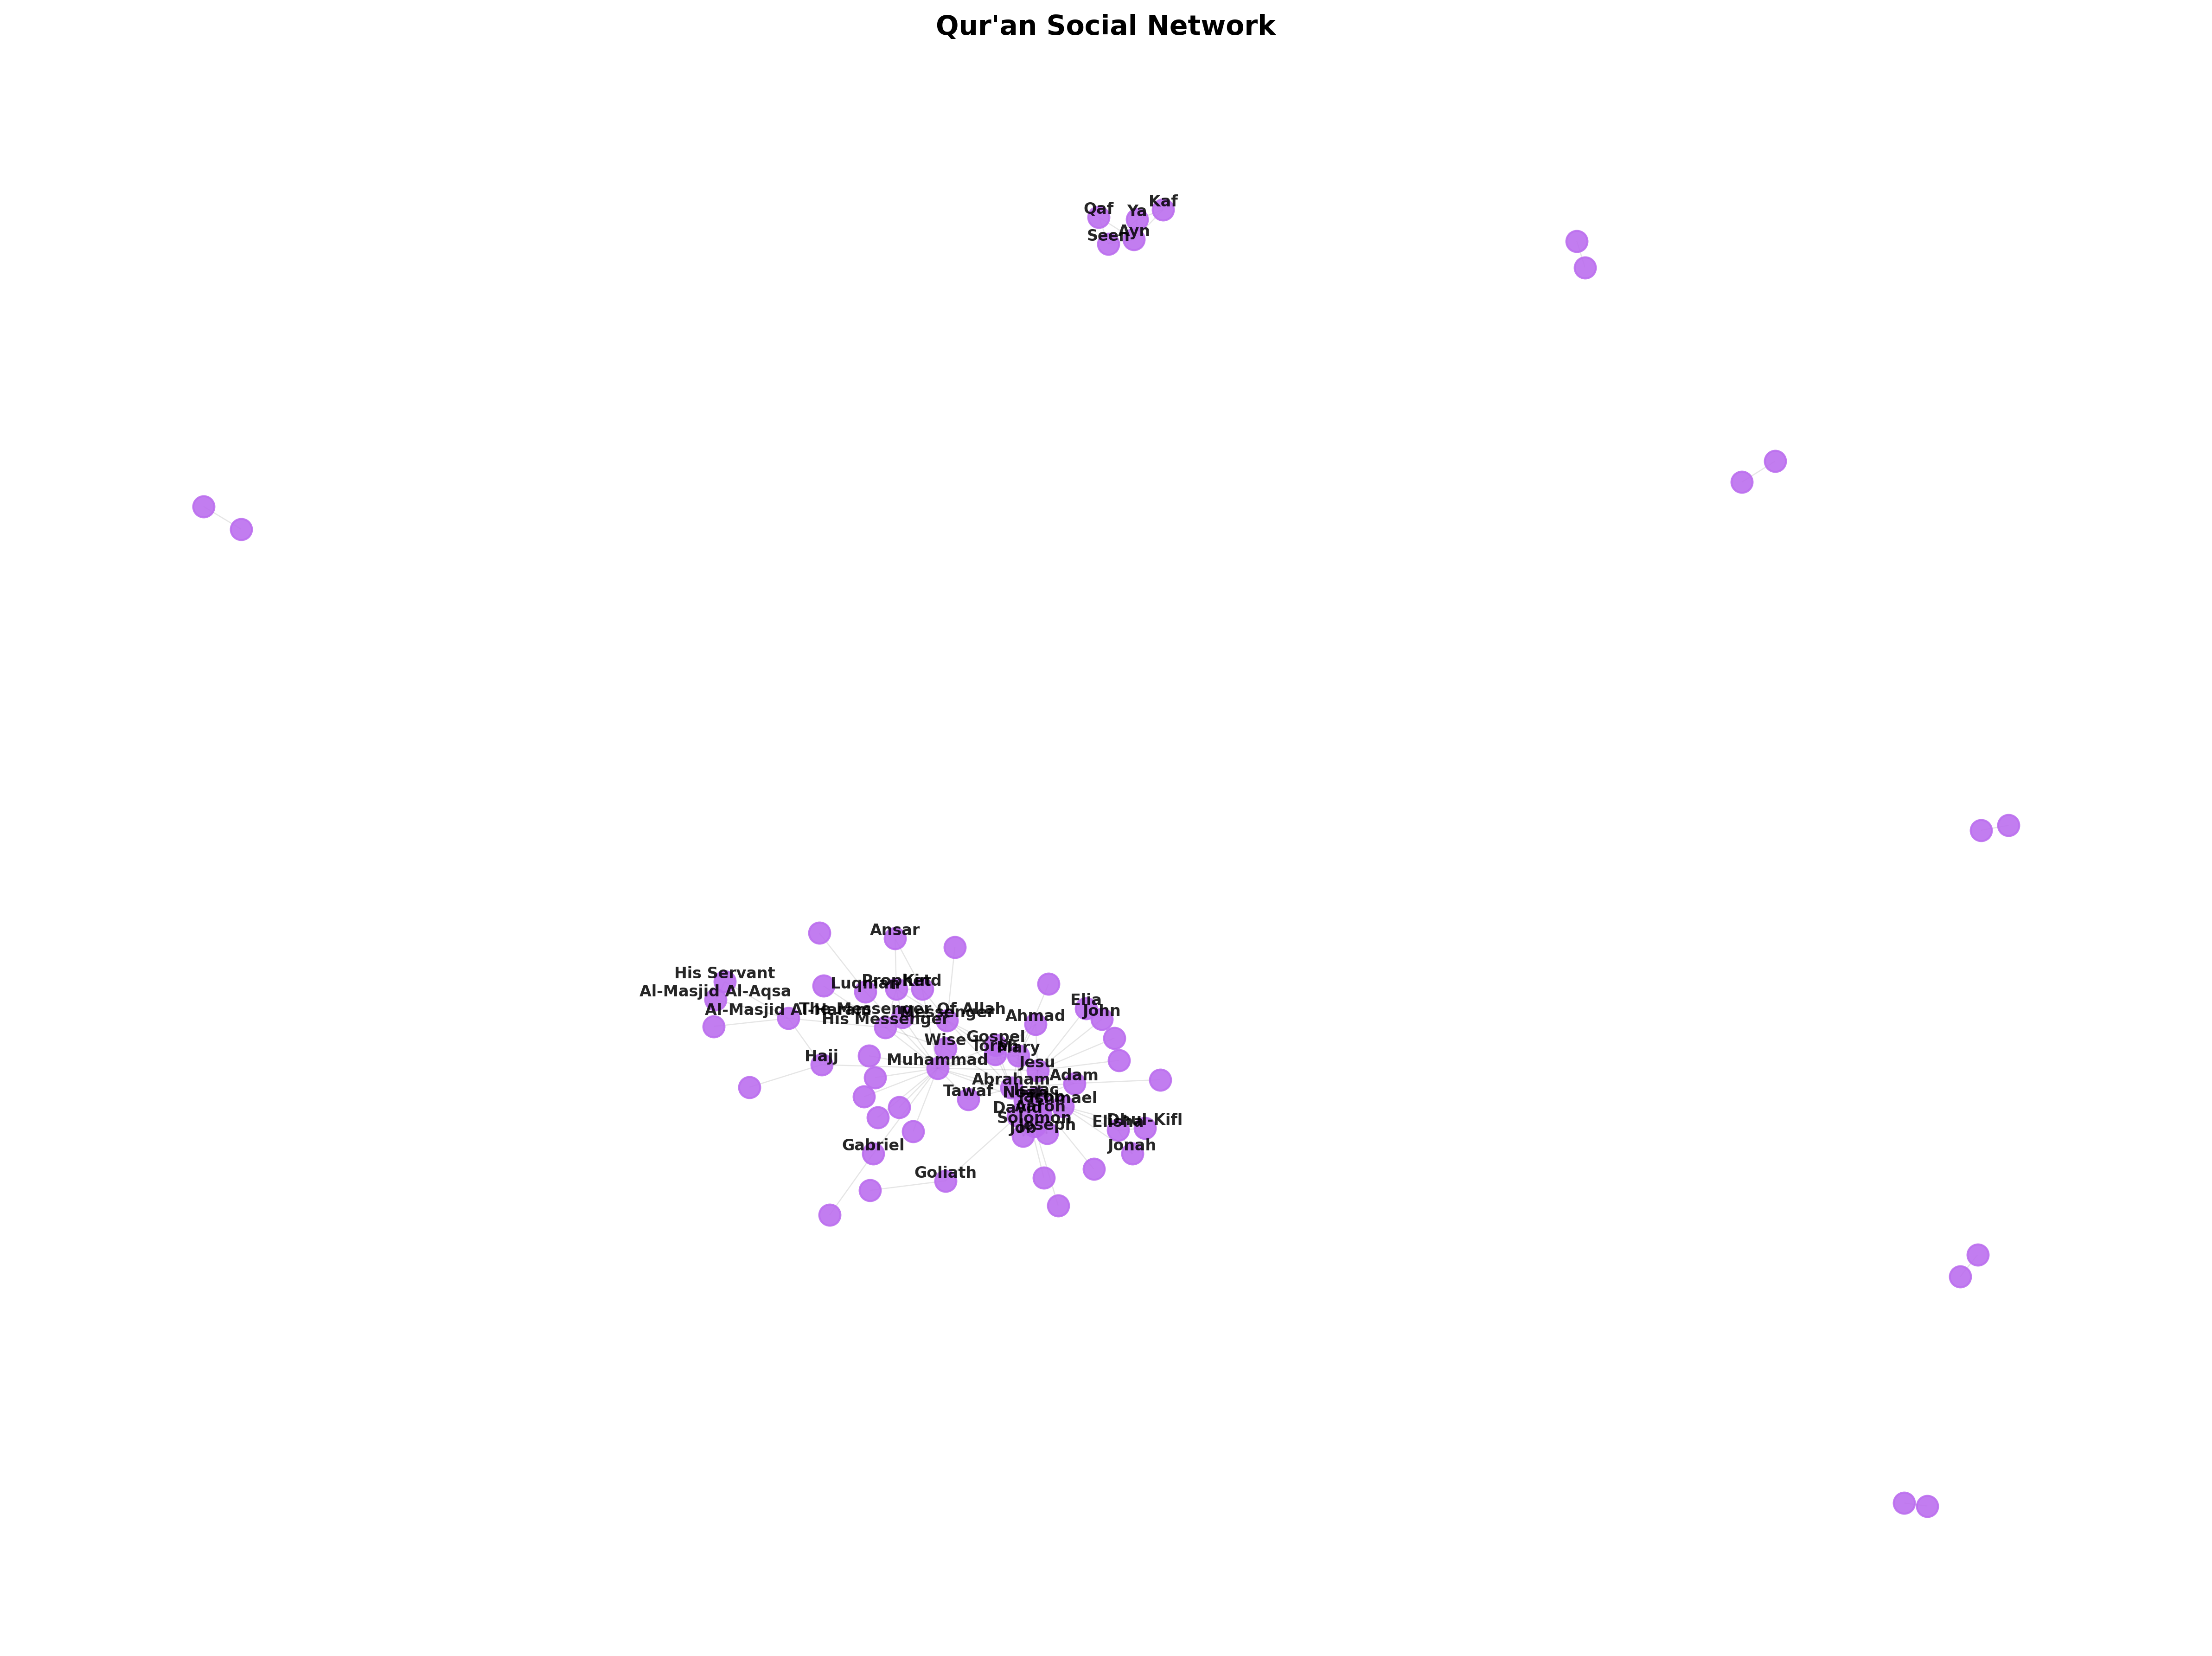

In [17]:
degrees = dict(G_quran.degree())

plt.figure(figsize=(16, 12), dpi=300)
pos = nx.spring_layout(G_quran, weight='weight', k=0.15, iterations=100, seed=42)
nx.draw_networkx_edges(G_quran, pos, alpha=0.1, edge_color="black", width=0.6)

# nodes
nx.draw_networkx_nodes(
    G_quran,
    pos,
    node_size=120,         
    node_color="#BC6FEF",   
    alpha=0.9
)

labels = {node: node if deg > 1 else "" for node, deg in degrees.items()}

nx.draw_networkx_labels(
    G_quran, 
    pos, 
    labels=labels, 
    font_size=8, 
    font_family="sans-serif",
    font_weight="bold",
    alpha=0.85,
    verticalalignment="bottom"
)

plt.title("Qur'an Social Network", fontsize=14, fontweight="bold", pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

### Comparative Analysis